# EDA

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
def get_data(directory="data", filename=""):
    file_path = os.path.join(directory, filename)
    return pd.read_csv(file_path)

In [3]:
raw_training_data = get_data(filename="training.csv")
raw_validation_data = get_data(filename="validation.csv")
raw_test_data = get_data(filename="test.csv")

In [4]:
print("NUMBER OF TWEETS")
print(f"Training data: {len(raw_training_data)}")
print(f"Validation data: {len(raw_validation_data)}")
print(f"Test data: {len(raw_test_data)}")

NUMBER OF TWEETS
Training data: 16000
Validation data: 2000
Test data: 2000


In [5]:
print("CHARACTERS PER TWEET")
print(f"Training data: mean - {raw_training_data["text"].str.len().mean()}, min - {raw_training_data["text"].str.len().min()}, max - {raw_training_data["text"].str.len().max()}")
print(f"Validation data: mean - {raw_validation_data["text"].str.len().mean()}, min - {raw_validation_data["text"].str.len().min()}, max - {raw_validation_data["text"].str.len().max()}")
print(f"Test data: mean - {raw_test_data["text"].str.len().mean()}, min - {raw_test_data["text"].str.len().min()}, max - {raw_test_data["text"].str.len().max()}")

CHARACTERS PER TWEET
Training data: mean - 96.8458125, min - 7, max - 300
Validation data: mean - 95.3475, min - 11, max - 295
Test data: mean - 96.5865, min - 14, max - 296


In [6]:
num_labels = len(raw_training_data["label"].unique())
print(f"Number of labels in the data: {num_labels}")

Number of labels in the data: 6


In [7]:
idx_to_label = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise"
}

In [8]:
from nltk import word_tokenize

In [9]:
def word(data_set):
    l = len(data_set)
    s = []
    for word in data_set["text"]:
        s.append(len(word_tokenize(word)))
    
    return pd.Series(s)

print(f"NUMBER OF WORDS")
print(f"In training data: {word(raw_training_data).describe()}")
print(f"In validation data: {word(raw_validation_data).describe()}")
print(f"In test data: {word(raw_test_data).describe()}")

NUMBER OF WORDS
In training data: count    16000.000000
mean        19.175313
std         10.992725
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
dtype: float64
In validation data: count    2000.000000
mean       18.877000
std        10.818058
min         2.000000
25%        10.000000
50%        17.000000
75%        25.000000
max        61.000000
dtype: float64
In test data: count    2000.000000
mean       19.161000
std        11.015432
min         3.000000
25%        10.750000
50%        17.000000
75%        26.000000
max        61.000000
dtype: float64


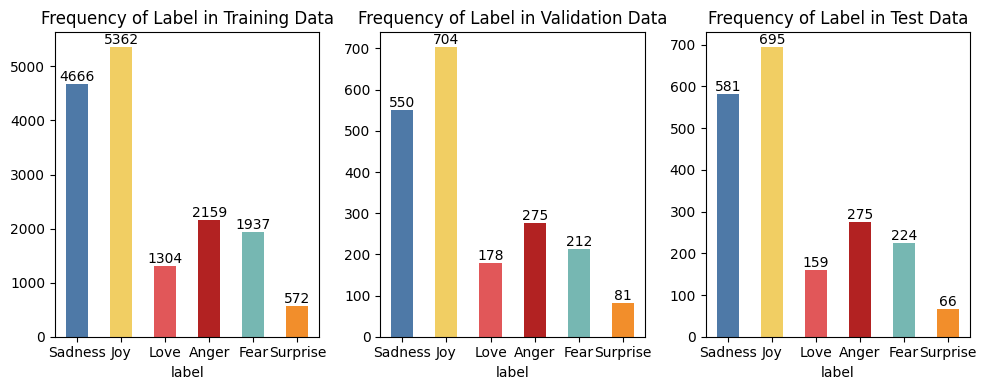

In [10]:
def plot_class_frequency(data, type=""):
    raw = data["label"].value_counts().sort_index().rename(index=idx_to_label)
    return raw


raw_training_label = plot_class_frequency(raw_training_data)
raw_validation_label = plot_class_frequency(raw_validation_data)
raw_test_label = plot_class_frequency(raw_test_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# First subplot
raw_training_label.plot(kind='bar', 
                        ax=axes[0],
                        rot=0,
                        color = ['#4E79A7', '#F1CE63', '#E15759', '#B22222', '#76B7B2', '#F28E2B'],
                        title=f"Frequency of Label in Training Data")
for i, v in enumerate(raw_training_label.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')


raw_validation_label.plot(kind='bar', 
                        ax=axes[1],
                        rot=0,
                        color = ['#4E79A7', '#F1CE63', '#E15759', '#B22222', '#76B7B2', '#F28E2B'],
                        title=f"Frequency of Label in Validation Data")
for i, v in enumerate(raw_validation_label.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

raw_test_label.plot(kind='bar', 
                    ax=axes[2],
                    rot=0,
                    color = ['#4E79A7', '#F1CE63', '#E15759', '#B22222', '#76B7B2', '#F28E2B'],
                    title=f"Frequency of Label in Test Data")
for i, v in enumerate(raw_test_label.values):
    axes[2].text(i, v, str(v), ha='center', va='bottom')


plt.tight_layout()
plt.show()


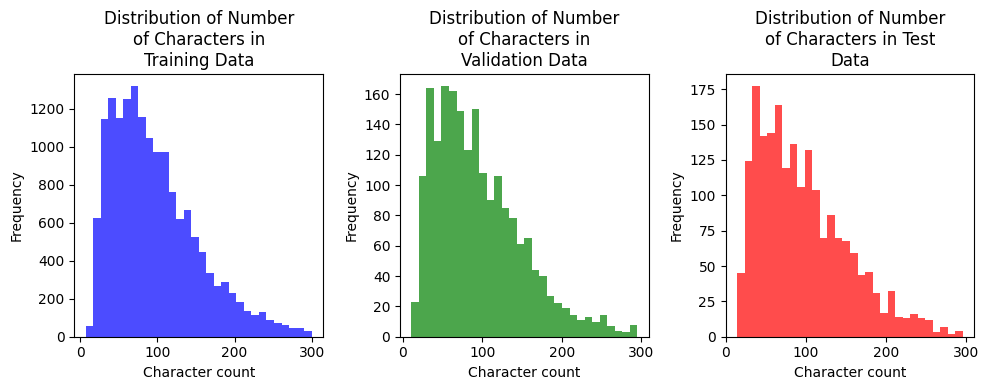

In [11]:
import textwrap
def character_length_distribution(data):
    l = [len(sentence) for sentence in data['text']]
    return pd.Series(l)
    
raw_training_character = character_length_distribution(raw_training_data)
raw_validation_character = character_length_distribution(raw_validation_data)
raw_test_character = character_length_distribution(raw_test_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))


# First subplot
raw_training_character.plot(kind='hist', 
                        bins=30,
                        ax=axes[0],
                        color="blue",
                        alpha=0.7,
                        title=f"Distribution of Number of Characters in Training Data")

axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Frequency')


raw_validation_character.plot(kind='hist', 
                        bins=30,
                        ax=axes[1],
                        color="green",
                        alpha=0.7,
                        title=f"Distribution of Number of Characters in Validation Data")

axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Frequency')


raw_test_character.plot(kind='hist', 
                        bins=30,
                        ax=axes[2],
                        color="red",
                        alpha=0.7,
                        title=f"Distribution of Number of Characters in Test Data")

axes[2].set_xlabel('Character count')
axes[2].set_ylabel('Frequency')

titles = [
    "Distribution of Number of Characters in Training Data",
    "Distribution of Number of Characters in Validation Data",
    "Distribution of Number of Characters in Test Data",
]
for ax, title in zip(axes, titles):
    ax.set_title(textwrap.fill(title, width=24))

plt.tight_layout()
plt.show()

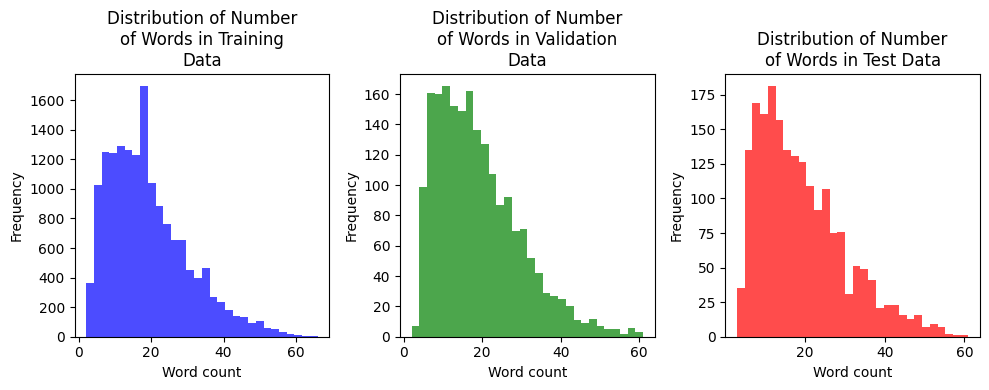

In [12]:
def word_length_distribution(data):
    l = [len(word_tokenize(sentence)) for sentence in data['text']]
    length = pd.Series(l)
    return length

raw_training_word = word_length_distribution(raw_training_data)
raw_validation_word = word_length_distribution(raw_validation_data)
raw_test_word = word_length_distribution(raw_test_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))


# First subplot
raw_training_word.plot(kind='hist', 
                        bins=30,
                        ax=axes[0],
                        color="blue",
                        alpha=0.7,
                        title=f"Distribution of Number of Words in Training Data")

axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')


raw_validation_word.plot(kind='hist', 
                        bins=30,
                        ax=axes[1],
                        color="green",
                        alpha=0.7,
                        title=f"Distribution of Number of Words in Validation Data")

axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')


raw_test_word.plot(kind='hist', 
                        bins=30,
                        ax=axes[2],
                        color="red",
                        alpha=0.7,
                        title=f"Distribution of Number of Words in Test Data")

axes[2].set_xlabel('Word count')
axes[2].set_ylabel('Frequency')

titles = [
    "Distribution of Number of Words in Training Data",
    "Distribution of Number of Words in Validation Data",
    "Distribution of Number of Words in Test Data",
]
for ax, title in zip(axes, titles):
    ax.set_title(textwrap.fill(title, width=24))

plt.tight_layout()
plt.show()

In [13]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from collections import Counter

In [15]:
def count_stopwords(data):
    all_words = []
    total_words = 0
    for text in data['text']:
        words = nltk.word_tokenize(text)
        total_words += len(words)
        all_words.extend([w.lower() for w in words if w.lower() in stop_words])

    stopwords_count = Counter(all_words)
    num = 0
    for word in stopwords_count:
        num += stopwords_count[word]
    l = [len(sentence) for sentence in raw_training_data['text']]
    return len(stopwords_count), num, round(float(num) / total_words, 4)


In [16]:
num_unique_stopwords, num_stopwords, percentage = count_stopwords(raw_training_data)
print(f"Training data has {num_unique_stopwords} unique stopwords,\nwith {num_stopwords} stopwords,\n{percentage * 100}% of total number of words")

Training data has 148 unique stopwords,
with 157168 stopwords,
51.23% of total number of words


In [17]:
num_unique_stopwords, num_stopwords, percentage = count_stopwords(raw_validation_data)
print(f"Validation data has {num_unique_stopwords} unique stopwords,\nwith {num_stopwords} stopwords,\n{percentage * 100}% of total number of words")

Validation data has 143 unique stopwords,
with 19357 stopwords,
51.27% of total number of words


In [18]:
num_unique_stopwords, num_stopwords, percentage = count_stopwords(raw_test_data)
print(f"Test data has {num_unique_stopwords} unique stopwords,\nwith {num_stopwords} stopwords,\n{percentage * 100}% of total number of words")

Test data has 140 unique stopwords,
with 19717 stopwords,
51.449999999999996% of total number of words


In [19]:
def plot_stopwords(data, top_n=10, dtype="Training", cl="blue"):
    all_words = []
    total_words = 0
    for text in data['text']:
        words = nltk.word_tokenize(text)
        total_words += len(words)
        all_words.extend([w.lower() for w in words if w.lower() in stop_words])

    stopwords_count = Counter(all_words)
    most_common = stopwords_count.most_common(top_n)

    words = [w for w, _ in most_common]
    counts = [c for _, c in most_common]

    # Plot
    plt.figure()
    plt.bar(words, counts, color=cl, alpha=0.7)
    plt.xticks(rotation=45)
    plt.xlabel("Stopwords")
    plt.ylabel("Frequency")
    plt.title(f"Top Stopwords Frequency in {dtype} data")
    plt.tight_layout()
    plt.show()

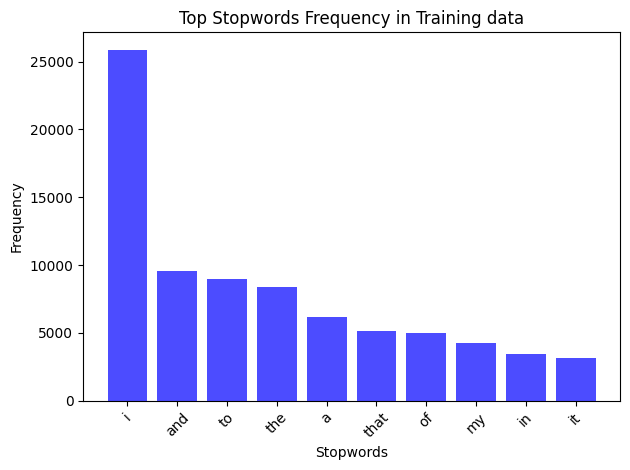

In [20]:
plot_stopwords(raw_training_data)

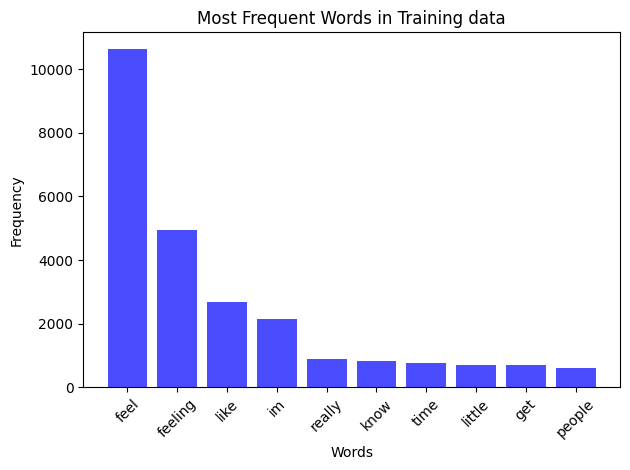

In [21]:
def frequent_word(data, custom_stopword=set(), dtype="Training", top_n=10, cl="blue"):
    all_words = []
    total_stop = stop_words | custom_stopword
    for text in data['text']:
        words = list(set(nltk.word_tokenize(text)))
        all_words.extend([w.lower() for w in words if w.lower() not in total_stop])

    stopwords_count = Counter(all_words)
    most_common = stopwords_count.most_common(top_n)

    words = [w for w, _ in most_common]
    counts = [c for _, c in most_common]

    # Plot
    plt.figure()
    plt.bar(words, counts, color=cl, alpha=0.7)
    plt.xticks(rotation=45)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.title(f"Most Frequent Words in {dtype} data")
    plt.tight_layout()
    plt.show()

    return most_common

most_cm = [term[0] for term in frequent_word(raw_training_data)]

In [22]:
def vocabulary_richness(data):
    result = []
    for i in range(6):
        filtered = data[data['label'] == i]
        total_len = 0
        vocabulary = set()
        for tweet in filtered["text"]:
            tokens = set(word_tokenize(tweet)).difference(stop_words)
            total_len += len(tokens)
            vocabulary = vocabulary | tokens
        result.append({
            "name": idx_to_label[i],
            "num_of_words": len(vocabulary),
            "total_num_of_words": total_len,
            "type-token-ratio": round(len(vocabulary) / float(total_len), 3)
        })
    return result

vocabulary_richness(raw_training_data)

[{'name': 'Sadness',
  'num_of_words': 6867,
  'total_num_of_words': 40701,
  'type-token-ratio': 0.169},
 {'name': 'Joy',
  'num_of_words': 8500,
  'total_num_of_words': 49504,
  'type-token-ratio': 0.172},
 {'name': 'Love',
  'num_of_words': 3698,
  'total_num_of_words': 12554,
  'type-token-ratio': 0.295},
 {'name': 'Anger',
  'num_of_words': 4671,
  'total_num_of_words': 19440,
  'type-token-ratio': 0.24},
 {'name': 'Fear',
  'num_of_words': 4254,
  'total_num_of_words': 17317,
  'type-token-ratio': 0.246},
 {'name': 'Surprise',
  'num_of_words': 2041,
  'total_num_of_words': 5419,
  'type-token-ratio': 0.377}]

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
def tf_idf_top_term(data, custom_stopword):
    total_stop = stop_words | set(custom_stopword)
    vectorizer = TfidfVectorizer(max_features=5000, stop_words=list(total_stop))
    tfidf_matrix = vectorizer.fit_transform(data['text'])
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Top 10 TF-IDF Terms by Category', fontsize=16, y=0.995)

    categories = sorted(data['label'].unique())
    colors = ['#4E79A7', '#F1CE63', '#E15759', '#B22222', '#76B7B2', '#F28E2B']

    for idx, category in enumerate(categories):
        ax = axes[idx // 3, idx % 3]
        
        # Get TF-IDF for this category
        cat_indices = data[data['label'] == category].index
        cat_tfidf = tfidf_matrix[cat_indices]
        
        # Calculate mean TF-IDF scores
        mean_scores = np.array(cat_tfidf.mean(axis=0)).flatten()
        
        # Get top 10
        top_indices = mean_scores.argsort()[-10:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_scores = [mean_scores[i] for i in top_indices]
        
        # Plot
        ax.barh(top_words, top_scores, color=colors[idx], alpha=0.7)
        ax.set_title(idx_to_label[category].capitalize(), fontsize=12, fontweight='bold')
        ax.set_xlabel('TF-IDF Score', fontsize=10)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)


    plt.tight_layout()
    plt.show()

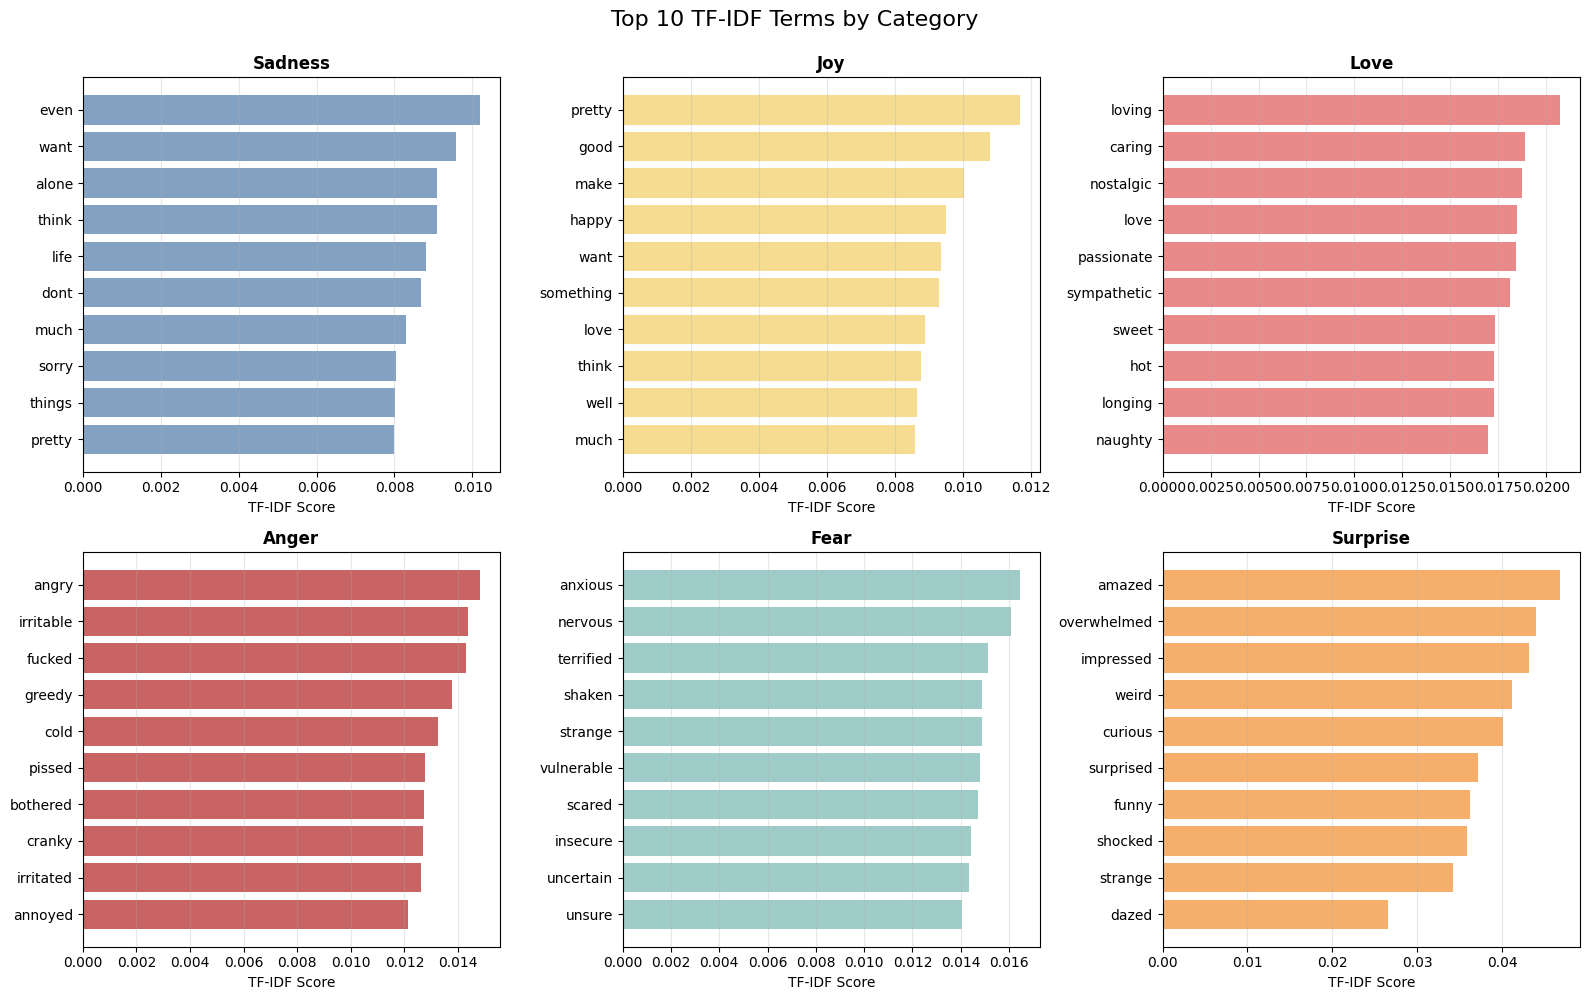

In [25]:
custom_stopword = most_cm + ["ive", "bit", "still", "would", "one"]
tf_idf_top_term(raw_training_data, custom_stopword=custom_stopword)

In [26]:
def tf_idf_top_term_bigram(data, custom_stopword):
    total_stop = stop_words | set(custom_stopword)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Top 10 TF-IDF Terms by Category', fontsize=16, y=0.995)

    categories = sorted(data['label'].unique())
    colors = ['#4E79A7', '#F1CE63', '#E15759', '#B22222', '#76B7B2', '#F28E2B']

    for idx, category in enumerate(categories):
        ax = axes[idx // 3, idx % 3]
        
        cat_df = data[data['label'] == category]
        # Combine all articles into one text (same as report)
        combined_text = ' '.join(cat_df['text'].values)
        vectorizer = TfidfVectorizer(
            ngram_range=(2, 2),
            max_features=30,
            stop_words=list(total_stop)
        )
        tfidf_matrix = vectorizer.fit_transform([combined_text])
        feature_names = vectorizer.get_feature_names_out()
        tfidf_scores = tfidf_matrix.toarray()[0]

        
        # Get top 10
        top_indices = tfidf_scores.argsort()[-10:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_scores = [tfidf_scores[i] for i in top_indices]
        
        # Plot
        ax.barh(top_words, top_scores, color=colors[idx], alpha=0.7)
        ax.set_title(idx_to_label[category].capitalize(), fontsize=12, fontweight='bold')
        ax.set_xlabel('TF-IDF Score', fontsize=10)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)


    plt.tight_layout()
    plt.show()

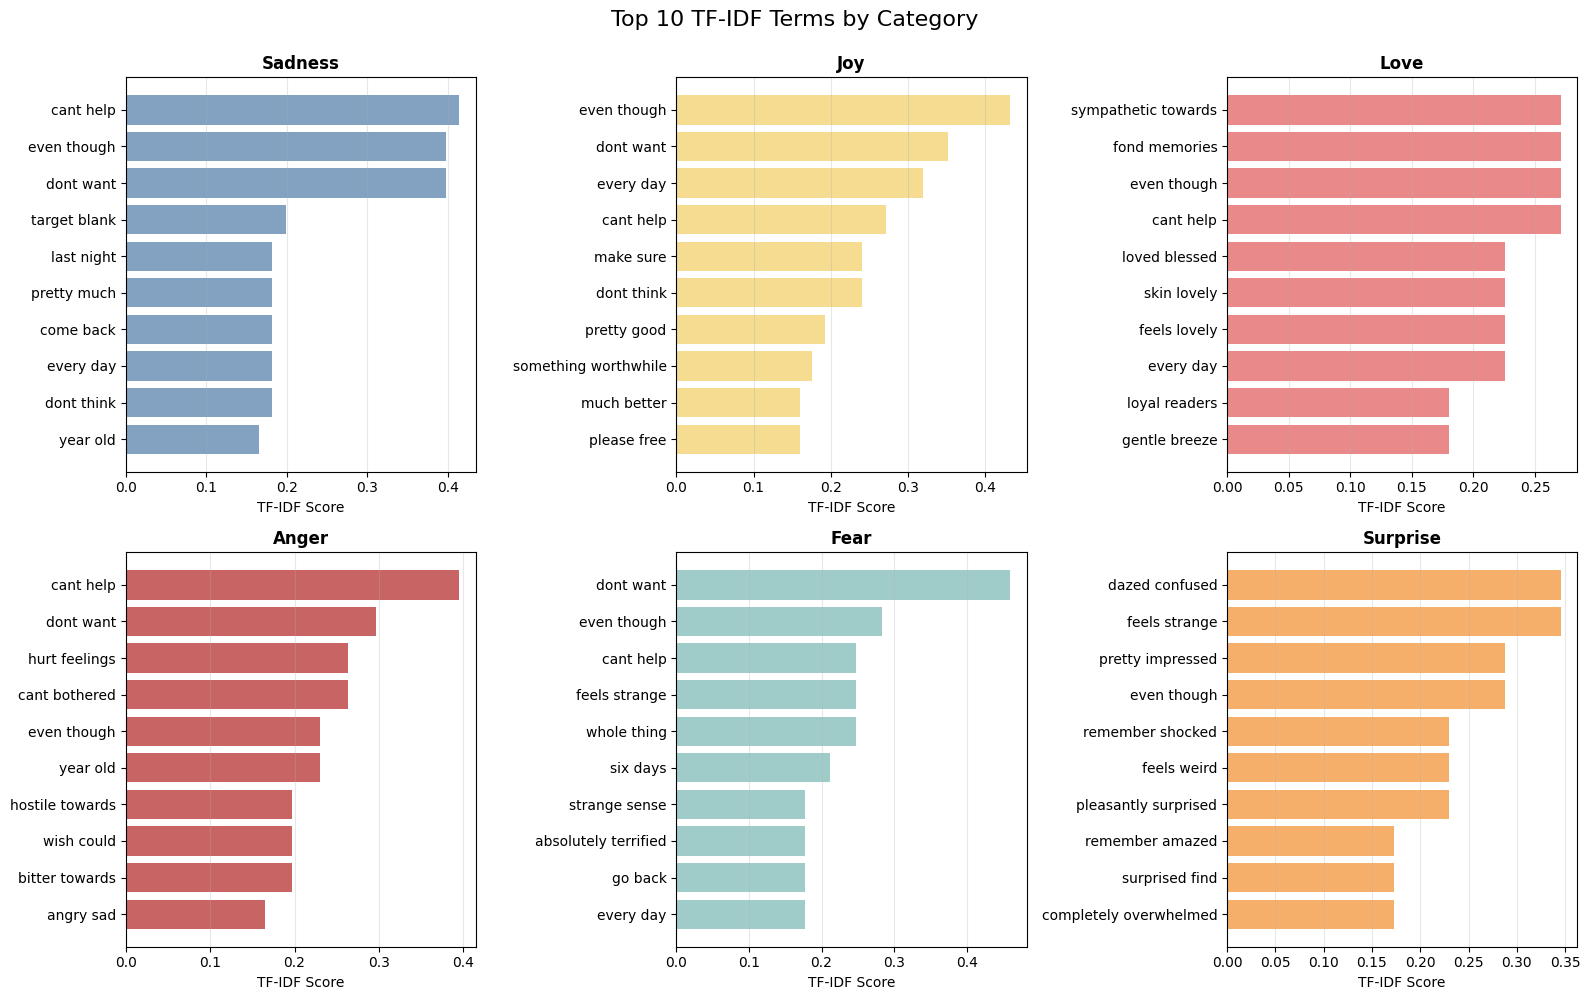

In [27]:
custom_stopword = most_cm + ["ive", "bit", "still", "would", "one", "href", "http", "img", "src"]
tf_idf_top_term_bigram(raw_training_data, custom_stopword=custom_stopword)

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
def similarity_matrix(df):
    categories = sorted(df['label'].unique())
    vectorizer = TfidfVectorizer(max_features=5000, stop_words=list(stop_words))
    tfidf_matrix = vectorizer.fit_transform(df['text'])

    # Calculate mean similarity between each pair of categories
    n_cats = len(categories)
    similarity_matrix = np.zeros((n_cats, n_cats))

    for i, cat1 in enumerate(categories):
        cat1_indices = df[df['label'] == cat1].index
        cat1_vectors = tfidf_matrix[cat1_indices]
        
        for j, cat2 in enumerate(categories):
            cat2_indices = df[df['label'] == cat2].index
            cat2_vectors = tfidf_matrix[cat2_indices]
            
            # Compute pairwise similarities
            pairwise_sim = cosine_similarity(cat1_vectors, cat2_vectors)
            
            # Take mean (diagonal != 1.0)
            similarity_matrix[i, j] = np.mean(pairwise_sim)

    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(similarity_matrix, cmap='Purples', aspect='auto')
    category_names = [idx_to_label[idx] for idx in categories]
    # Set ticks and labels
    ax.set_xticks(np.arange(len(categories)))
    ax.set_yticks(np.arange(len(categories)))
    ax.set_xticklabels(category_names)
    ax.set_yticklabels(category_names)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Similarity Score', rotation=270, labelpad=20)

    # Add text annotations
    for i in range(len(categories)):
        for j in range(len(categories)):
            text = ax.text(j, i, f'{similarity_matrix[i, j]:.3f}',
                        ha="center", va="center", 
                        color="white" if similarity_matrix[i, j] > 0.5 else "black",
                        fontsize=10, fontweight='bold')

    ax.set_title('Category Similarity Matrix', fontsize=16, pad=20)
    ax.set_xlabel('Category', fontsize=12)
    ax.set_ylabel('Category', fontsize=12)

    plt.tight_layout()
    plt.show()


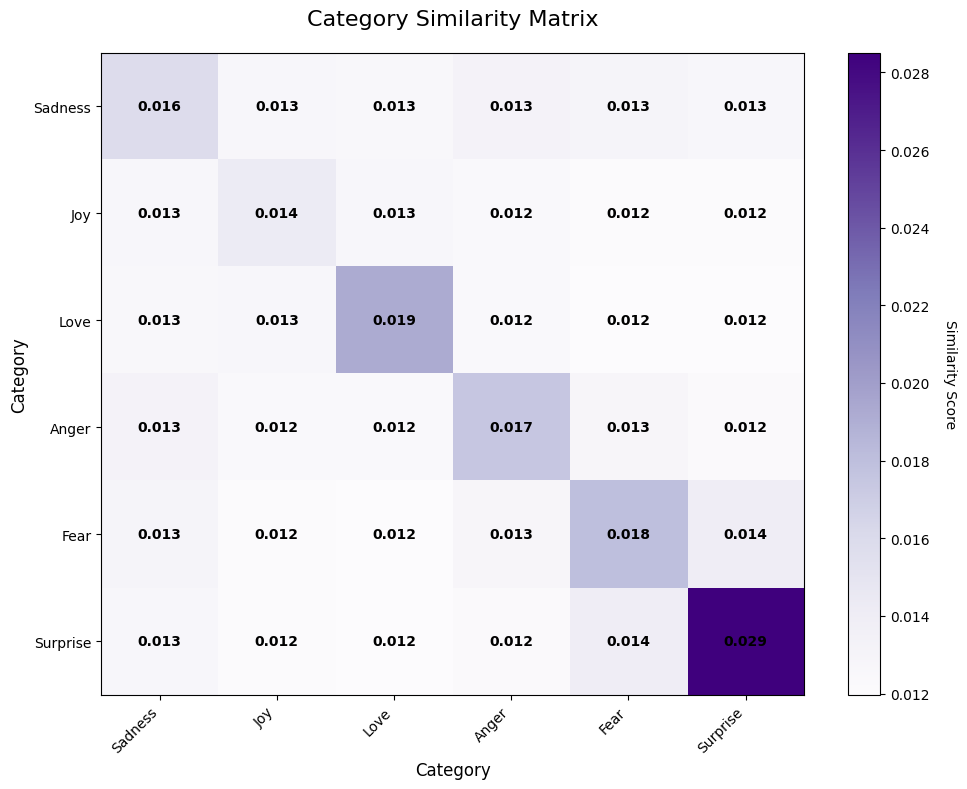

In [29]:
similarity_matrix(raw_training_data)

# LSTM

## Prepare training data

In [30]:
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
import torch
from nltk import word_tokenize

In [31]:
# Embedding using a global embedding vector - "glove.6B.100d.txt" (https://nlp.stanford.edu/projects/glove/)
glove_path = "glove.6B/glove.6B.100d.txt"
embedding_dim = 100

glove_dict = {}

with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_dict[word] = vector

In [32]:
# Build a vocabulary from the training set
def build_vocabulary(data):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    all_tokens = []
    for sentence in data["text"]:
        all_tokens.extend([token for token in word_tokenize(sentence)])
    for word, _ in Counter(all_tokens).items():
        vocab[word] = len(vocab)

    
    return vocab

vocab = build_vocabulary(raw_training_data)
print(vocab)

{'<PAD>': 0, '<UNK>': 1, 'i': 2, 'didnt': 3, 'feel': 4, 'humiliated': 5, 'can': 6, 'go': 7, 'from': 8, 'feeling': 9, 'so': 10, 'hopeless': 11, 'to': 12, 'damned': 13, 'hopeful': 14, 'just': 15, 'being': 16, 'around': 17, 'someone': 18, 'who': 19, 'cares': 20, 'and': 21, 'is': 22, 'awake': 23, 'im': 24, 'grabbing': 25, 'a': 26, 'minute': 27, 'post': 28, 'greedy': 29, 'wrong': 30, 'am': 31, 'ever': 32, 'nostalgic': 33, 'about': 34, 'the': 35, 'fireplace': 36, 'will': 37, 'know': 38, 'that': 39, 'it': 40, 'still': 41, 'on': 42, 'property': 43, 'grouchy': 44, 'ive': 45, 'been': 46, 'little': 47, 'burdened': 48, 'lately': 49, 'wasnt': 50, 'sure': 51, 'why': 52, 'was': 53, 'taking': 54, 'or': 55, 'milligrams': 56, 'times': 57, 'recommended': 58, 'amount': 59, 'fallen': 60, 'asleep': 61, 'lot': 62, 'faster': 63, 'but': 64, 'also': 65, 'like': 66, 'funny': 67, 'as': 68, 'confused': 69, 'life': 70, 'teenager': 71, 'jaded': 72, 'year': 73, 'old': 74, 'man': 75, 'have': 76, 'with': 77, 'petronas'

In [33]:
def build_embedding_matrix(vocab):
    embedding_matrix = np.zeros((len(vocab), embedding_dim))

    for word, idx in vocab.items():
        if word in glove_dict:
            embedding_matrix[idx] = glove_dict[word]
        else:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
    
    return embedding_matrix

embedding_matrix = build_embedding_matrix(vocab)

In [34]:
np.save("space/model/lstm/embedding_matrix.npy", embedding_matrix)

In [35]:
def prepare_data(data, vocab):
    # Return the padded text and labels 
    data["text"] = data["text"].str.lower()
    data["tokens"] = data["text"].apply(word_tokenize)

    data['ids'] = data['tokens'].apply(
        lambda tokens: [vocab.get(tok, vocab['<UNK>']) for tok in tokens]
    )

    sequences = [torch.tensor(seq) for seq in data['ids']]

    padded = pad_sequence(sequences, batch_first=True, padding_value=0)

    return padded, data['label']

training_data, label = prepare_data(data=raw_training_data, vocab=vocab)

## LSTM Model

In [36]:
import torch.nn as nn
from huggingface_hub import PyTorchModelHubMixin

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
class LSTMClassifier(nn.Module, PyTorchModelHubMixin):
    def __init__(self, 
                 embedding_dim=100, 
                 hidden_dim=512, 
                 output_dim=6, 
                 n_layers=2, 
                 bidirectional=True, 
                 dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=True
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, 
                            bidirectional=bidirectional, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(lstm_output_dim, output_dim)
        
    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        _, (hidden, _) = self.lstm(embedded)
        
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        else:
            hidden = self.dropout(hidden[-1, :, :])
        
        predictions = self.fc(hidden)
        
        return predictions



In [38]:
model_lstm = LSTMClassifier(n_layers=2 ,bidirectional=True, output_dim=num_labels)
print(model_lstm)
print(f"\nTotal parameters: {sum(p.numel() for p in model_lstm.parameters()):,}")

LSTMClassifier(
  (embedding): Embedding(15212, 100)
  (lstm): LSTM(100, 512, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=1024, out_features=6, bias=True)
)

Total parameters: 10,341,942


## Training

In [39]:
from torch.utils.data import TensorDataset, DataLoader
from safetensors.torch import save_file

In [40]:
# Use only when balancing classes
sum_weight = raw_training_label.values.sum()
weight_classes = torch.sqrt(sum_weight / (num_labels * torch.tensor(raw_training_label.values)))

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = model_lstm.to(device)

try:
    weight_classes = weight_classes.to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_classes)
except NameError:
    criterion = nn.CrossEntropyLoss()

print(f"Model on device: {device}")

optimizer = torch.optim.AdamW(model_lstm.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Model on device: cuda


In [42]:
raw_validation_data = get_data(filename="validation.csv")
validation_data, validation_label = prepare_data(data=raw_validation_data, vocab=vocab)

In [43]:
def train_epoch(model, training, validation, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for _, batch in enumerate(training):
        optimizer.zero_grad()
        
        text = batch['text'].to(device)
        labels = batch['label'].to(device)
        
        predictions = model(text)

        predictions.to(device)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(predictions.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = epoch_loss / len(training)
    train_acc = correct / total

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for _, batch in enumerate(validation):
            text = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            predictions = model(text)
            loss = criterion(predictions, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(predictions.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    validation_loss = val_loss / len(validation)
    validation_acc = val_correct / val_total

    return train_loss, train_acc, validation_loss, validation_acc

In [44]:
class BatchWrapper:
    def __init__(self, loader):
        self.loader = loader
    
    def __iter__(self):
        for batch in self.loader:
            text, label = batch
            yield {'text': text, 'label': label}
    
    def __len__(self):
        return len(self.loader)

In [45]:
def wrap_data(dataset, label, batch_size=32):
    label_torch = torch.tensor(label, dtype=torch.long)
    dataset_tensor = TensorDataset(dataset, label_torch)
    loader = DataLoader(dataset_tensor, batch_size=batch_size, shuffle=True)
    return BatchWrapper(loader)

In [46]:
from torch.utils.data import WeightedRandomSampler

In [47]:
def wrap_data_imbalance(dataset, label, batch_size=32):
    label_torch = torch.tensor(label, dtype=torch.long)
    dataset_tensor = TensorDataset(dataset, label_torch)

    class_counts = torch.bincount(label_torch)
    sum = class_counts.sum().item()
    num_classes = len(class_counts)
    weights = float(sum) / (class_counts * num_classes)
    sample_weights = weights[label_torch]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    loader = DataLoader(dataset_tensor, batch_size=batch_size, sampler=sampler)
    return BatchWrapper(loader)

In [48]:
def train(model, data, label, validation_data, validation_label, link, batch_size=32, num_epochs=20, handle_imbalance=False):
    train_loader = None
    if handle_imbalance:
        train_loader = wrap_data_imbalance(data, label, batch_size)
    else:
        train_loader = wrap_data(data, label, batch_size)
    validation_loader = wrap_data(validation_data, validation_label, batch_size)

    patience, patience_counter = 3, 0   

    training_losses = []
    training_accs = []
    validation_losses = []
    validation_accs = []

    best_val_acc = 0

    print("START TRAINING")
    for epoch in range(num_epochs):
        train_loss, train_acc, val_loss, val_acc = train_epoch(model, train_loader, validation_loader, optimizer, criterion, device)
        training_losses.append(train_loss)
        training_accs.append(train_acc)
        validation_losses.append(val_loss)
        validation_accs.append(val_acc)
        
        if epoch == 0 or val_acc > best_val_acc:
            best_val_acc = val_acc
            save_file(model.state_dict(), link)
            patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


    print(f"Best validation accuracy: {best_val_acc:.4f}")

In [49]:
raw_validation_data = get_data(filename="validation.csv")
validation_data, validation_label = prepare_data(data=raw_validation_data, vocab=vocab)

In [50]:
import time

In [51]:
start = time.time()
train(model_lstm, training_data, label, validation_data, validation_label, num_epochs=100, link="space/model/lstm/lstm_model_weighted_loss.safetensors", handle_imbalance=True)
end = time.time()
print(f"Training time: {end - start}")

START TRAINING
Epoch 1/100 | Train Loss: 1.4515 | Train Acc: 0.3124 | Val Loss: 1.3943 | Val Acc: 0.2715
Epoch 2/100 | Train Loss: 0.9474 | Train Acc: 0.5653 | Val Loss: 0.8890 | Val Acc: 0.6650
Epoch 3/100 | Train Loss: 0.6319 | Train Acc: 0.7300 | Val Loss: 0.5788 | Val Acc: 0.7865
Epoch 4/100 | Train Loss: 0.4896 | Train Acc: 0.7875 | Val Loss: 0.4023 | Val Acc: 0.8500
Epoch 5/100 | Train Loss: 0.3919 | Train Acc: 0.8271 | Val Loss: 0.3314 | Val Acc: 0.8750
Epoch 6/100 | Train Loss: 0.3251 | Train Acc: 0.8590 | Val Loss: 0.3239 | Val Acc: 0.8750
Epoch 7/100 | Train Loss: 0.2996 | Train Acc: 0.8699 | Val Loss: 0.3005 | Val Acc: 0.8830
Epoch 8/100 | Train Loss: 0.2947 | Train Acc: 0.8701 | Val Loss: 0.3021 | Val Acc: 0.8825
Epoch 9/100 | Train Loss: 0.2740 | Train Acc: 0.8776 | Val Loss: 0.2927 | Val Acc: 0.8845
Epoch 10/100 | Train Loss: 0.2658 | Train Acc: 0.8815 | Val Loss: 0.2833 | Val Acc: 0.8895
Epoch 11/100 | Train Loss: 0.2612 | Train Acc: 0.8830 | Val Loss: 0.2782 | Val Acc: 

## Testing the Model

In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
import seaborn as sns
import time
from fvcore.nn import FlopCountAnalysis
from safetensors.torch import load_file

In [59]:
state_dict = load_file("space/model/lstm/lstm_model_weighted_sampler.safetensors")
model_lstm = LSTMClassifier()
model_lstm.load_state_dict(state_dict)

<All keys matched successfully>

In [53]:
def get_prediction_lstm(model, iterator, device, count_flop=True):
    model.to(device)
    model.eval()

    predict = []
    target = []

    total_time = 0
    if count_flop:
        total_flops = 0
    total_num = 0

    with torch.no_grad():
        for batch in iterator:
            text = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            if count_flop:
                flops = FlopCountAnalysis(model, text)
                total_flops += flops.total()

            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.time()
            predictions = model(text)
            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.time()

            total_time += (end - start)
            total_num += len(text)

            _, predicted = torch.max(predictions.data, 1)
            predict.append(predicted)
            target.append(labels)


    predict = torch.cat(predict, axis=0)
    target = torch.cat(target, axis=0)

    avg_time = float(total_time) / total_num
    if count_flop:
        avg_flops = float(total_flops) / total_num
    else:
        avg_flops = 0.0

    return predict, target, avg_time, avg_flops

In [54]:
raw_test_data = get_data(filename="test.csv")
test_data, test_label = prepare_data(data=raw_test_data, vocab=vocab)
test = wrap_data(test_data, test_label)

In [60]:
predicted, target, avg_time, avg_flops = get_prediction_lstm(model_lstm, test, device)
predicted = predicted.cpu().numpy()
target = target.cpu().numpy()

Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encountered 1 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::lstm encou

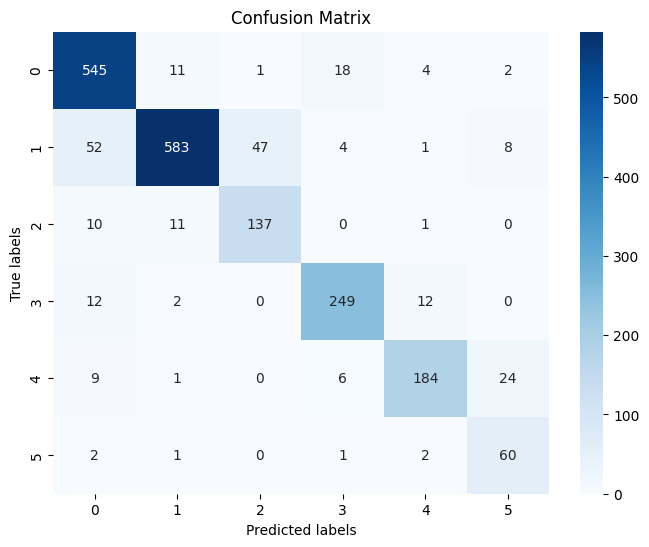

In [55]:
cm = confusion_matrix(target, predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [61]:
accuracy = accuracy_score(target, predicted)
precision = precision_score(target, predicted, average='weighted')
recall = recall_score(target, predicted, average="weighted")
print(f"Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Accuracy: 0.907 | Precision: 0.918 | Recall: 0.907


In [62]:
print(classification_report(target, predicted, digits=3))

              precision    recall  f1-score   support

           0      0.943     0.935     0.939       581
           1      0.973     0.875     0.921       695
           2      0.742     0.975     0.842       159
           3      0.902     0.942     0.922       275
           4      0.912     0.830     0.869       224
           5      0.636     0.955     0.764        66

    accuracy                          0.907      2000
   macro avg      0.851     0.918     0.876      2000
weighted avg      0.918     0.907     0.909      2000



In [58]:
print(f"Average predict time: {avg_time}")
print(f"Average FLOPs: {avg_flops}")

Average predict time: 0.0004731175899505615
Average FLOPs: 6144.0


## Quantization

In [63]:
from safetensors.torch import load_file

In [64]:
model_lstm_fp32 = LSTMClassifier(n_layers=2 ,bidirectional=True, output_dim=num_labels)
state_dict = load_file("space/model/lstm/lstm_model.safetensors")
model_lstm_fp32.load_state_dict(state_dict)

<All keys matched successfully>

In [67]:
model_lstm_fp32.to("cpu")
model_lstm_fp32.eval()

LSTMClassifier(
  (embedding): Embedding(15212, 100)
  (lstm): LSTM(100, 512, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=1024, out_features=6, bias=True)
)

In [68]:
quantized_lstm_model = torch.quantization.quantize_dynamic(
    model_lstm_fp32,
    {nn.Linear},
    dtype=torch.qint8
)

In [69]:
raw_test_data = get_data(filename="test.csv")
test_data, test_label = prepare_data(data=raw_test_data, vocab=vocab)
test = wrap_data(test_data, test_label)

In [75]:
predicted, target, avg_time, _ = get_prediction_lstm(quantized_lstm_model, test, torch.device("cpu"), False)

In [76]:
print(classification_report(target, predicted, digits=3))

              precision    recall  f1-score   support

           0      0.941     0.941     0.941       581
           1      0.928     0.927     0.927       695
           2      0.780     0.824     0.801       159
           3      0.926     0.905     0.915       275
           4      0.891     0.911     0.901       224
           5      0.797     0.712     0.752        66

    accuracy                          0.911      2000
   macro avg      0.877     0.870     0.873      2000
weighted avg      0.911     0.911     0.911      2000



In [77]:
print(f"Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Accuracy: 0.907 | Precision: 0.918 | Recall: 0.907


In [78]:
print(f"Average predict time: {avg_time}")

Average predict time: 0.005419706702232361


# Transformer

## Prepare Training Set

In [35]:
import torch
from transformers import AutoTokenizer, BertTokenizer
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

In [31]:
model_name = "prajjwal1/bert-tiny"
tokenizer = BertTokenizer.from_pretrained(model_name)

In [32]:
texts = raw_training_data["text"].tolist()
encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    return_tensors = None
)

In [36]:
class_counts = np.bincount(raw_training_data["label"])
alpha = 0.7
class_weights = (1.0 / class_counts) ** alpha
sample_weights = [class_weights[l] for l in raw_training_data["label"]]

In [37]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [38]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        super().__init__()
        self.encodings = encodings
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

labels = raw_training_data["label"].tolist()
train_dataset = TextDataset(encodings, labels)

In [39]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Import pre-trained model

In [40]:
from transformers import AutoModelForSequenceClassification, BertForSequenceClassification

In [41]:
model_transformer = BertForSequenceClassification.from_pretrained(
    "prajjwal1/bert-tiny",
    num_labels=6
)

Loading weights: 100%|██████████| 39/39 [00:00<00:00, 12981.34it/s]
BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored w

In [42]:
model_transformer.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-12, e

## Training the Model

In [43]:
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm
from sklearn.metrics import accuracy_score

In [44]:
optimizer = AdamW(model_transformer.parameters(), lr=1e-5, weight_decay=0.01)

In [45]:
num_epochs = 50
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    "linear",          
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

In [46]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training"):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [47]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc

In [48]:
raw_validation_data = get_data(filename="validation.csv")
texts_validation = raw_validation_data["text"].tolist()
labels_validation = raw_validation_data["label"].tolist()

In [49]:
encodings = tokenizer(
    texts_validation,
    truncation=True,
    padding=True,
    return_tensors = None
)
validation_dataset = TextDataset(encodings, labels_validation)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=True)

In [50]:
import time

In [51]:
def train(model, train_loader, validation_loader, optimizer, lr_scheduler, num_epochs, link):
    best_val_acc = 0
    patience, patience_counter = 3, 0   

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, lr_scheduler)
        val_acc    = evaluate(model, validation_loader)

        print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}", end="\n\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model.save_pretrained(link)
            tokenizer.save_pretrained(link)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    print(f"Best validation accuracy: {best_val_acc:.4f}")

start = time.time()
train(model_transformer, train_loader, validation_loader, optimizer, lr_scheduler, num_epochs, link="space/model/transformer_tinybert_imbalance")
end = time.time()
print(f"Time training: {end - start}")

Evaluating: 100%|██████████| 125/125 [00:00<00:00, 233.34it/s]


Epoch 1 | Loss: 1.7891 | Val Acc: 0.2685



Evaluating: 100%|██████████| 125/125 [00:00<00:00, 238.57it/s]


Epoch 2 | Loss: 1.7724 | Val Acc: 0.3470



Evaluating: 100%|██████████| 125/125 [00:00<00:00, 255.15it/s]


...

Epoch 30 | Loss: 0.2172 | Val Acc: 0.9000



Evaluating: 100%|██████████| 125/125 [00:00<00:00, 238.74it/s]


Epoch 31 | Loss: 0.2127 | Val Acc: 0.8980



Evaluating: 100%|██████████| 125/125 [00:00<00:00, 247.91it/s]

Epoch 32 | Loss: 0.2169 | Val Acc: 0.8995

Early stopping triggered.
Best validation accuracy: 0.9000
Time training: 435.29978704452515


## Testing

In [58]:
from sklearn.metrics import classification_report, confusion_matrix

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [62]:
model_transformer = AutoModelForSequenceClassification.from_pretrained("space/model/transformer_tinybert")
model_transformer.to(device)
tokenizer = AutoTokenizer.from_pretrained("space/model/transformer_tinybert")
model_transformer.eval()

Loading weights: 100%|██████████| 41/41 [00:00<00:00, 8173.31it/s]


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-12, e

In [63]:
raw_test_data = get_data(filename="test.csv")
texts_test = raw_test_data["text"].tolist()
target_test = raw_test_data["label"].tolist()

In [64]:
import time
from fvcore.nn import FlopCountAnalysis

In [65]:
def predict(model, tokenizer, texts: list[str], device, batch_size: int = 32):
    model.to(device)
    model.eval()
    
    inputs = tokenizer(texts, truncation=True, padding=True,
                       max_length=512, return_tensors="pt")
    
    total_time = 0.0
    total_flops = 0.0
    num_samples = len(texts)
    predictions = []
    
    with torch.no_grad():
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()

        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            batch_inputs = {k: v[start_idx:end_idx].to(device) for k, v in inputs.items()}

            logits = model(**batch_inputs).logits


            try:
                flops_inputs = (batch_inputs["input_ids"],)
                if "attention_mask" in batch_inputs:
                    flops_inputs = (batch_inputs["input_ids"], batch_inputs["attention_mask"])
                flops = FlopCountAnalysis(model, flops_inputs)
                total_flops += flops.total()
            except Exception:
                pass

            predictions.extend(logits.argmax(dim=-1).tolist())

        if device.type == "cuda":
            torch.cuda.synchronize()
        end = time.time()
        total_time = end - start

    avg_time = total_time / num_samples if num_samples else 0.0
    avg_flops = total_flops / num_samples if num_samples and total_flops else 0.0
    
    return predictions, avg_time, avg_flops

In [68]:
predicted, avg_time, avg_flop = predict(model_transformer, tokenizer, texts_test, torch.device("cpu"))

Unsupported operator aten::add encountered 8 time(s)
Unsupported operator aten::embedding encountered 3 time(s)
Unsupported operator aten::new_ones encountered 1 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 2 time(s)
Unsupported operator aten::gelu encountered 2 time(s)
Unsupported operator aten::tanh encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
bert.encoder.layer.0.attention.self.dropout, bert.encoder.layer.1.attention.self.dropout
Unsupported operator aten::add encountered 8 time(s)
Unsupported operator aten::embedding encountered 3 time(s)
Unsupported operator aten::new_ones encountered 1 time(s)
Unsupported operator aten::scaled_dot_product_attention encount

In [59]:
cr = classification_report(target_test, predicted, digits=3)
print(cr)

              precision    recall  f1-score   support

           0      0.962     0.916     0.938       581
           1      0.970     0.875     0.920       695
           2      0.682     0.943     0.792       159
           3      0.892     0.927     0.909       275
           4      0.874     0.839     0.856       224
           5      0.596     0.894     0.715        66

    accuracy                          0.896      2000
   macro avg      0.829     0.899     0.855      2000
weighted avg      0.911     0.896     0.900      2000



In [69]:
print(f"Average inference time: {avg_time}")
print(f"Average FLOPs: {avg_flop}")

Average inference time: 0.002987865924835205
Average FLOPs: 26180608.0


In [58]:
import seaborn as sns

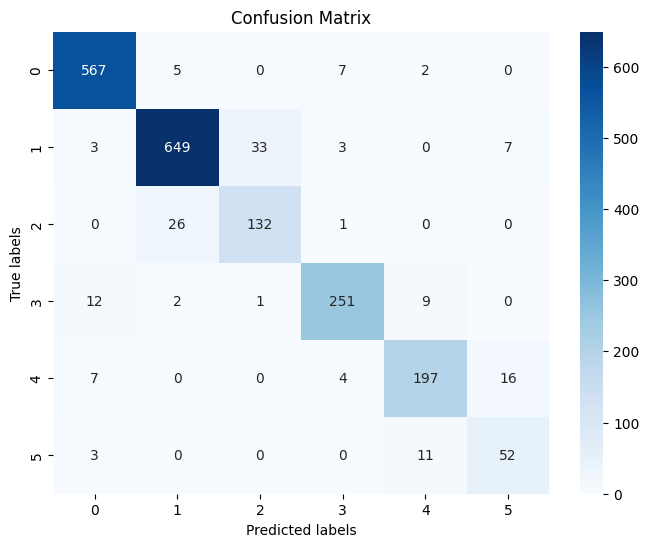

In [59]:
cm = confusion_matrix(target_test, predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

## Quantization

In [72]:
from optimum.quanto import quantize, qfloat8, freeze

In [70]:
quantized_model = AutoModelForSequenceClassification.from_pretrained("space/model/transformer_bert_imbalance")
tokenizer = AutoTokenizer.from_pretrained("space/model/transformer_bert_imbalance")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3654.65it/s]


In [73]:
quantize(quantized_model, weights=qfloat8, activations=qfloat8)
freeze(quantized_model)

In [74]:
predicted, avg_time, avg_flop = predict(quantized_model, tokenizer, texts_test, torch.device("cpu"))

In [75]:
cr = classification_report(target_test, predicted, digits=3)
print(cr)

              precision    recall  f1-score   support

           0      0.967     0.959     0.963       581
           1      0.936     0.945     0.941       695
           2      0.811     0.811     0.811       159
           3      0.924     0.924     0.924       275
           4      0.905     0.888     0.896       224
           5      0.750     0.773     0.761        66

    accuracy                          0.923      2000
   macro avg      0.882     0.883     0.883      2000
weighted avg      0.924     0.923     0.924      2000



In [79]:
print(f"Average inference time: {avg_time}")
print(f"Average FLOPs: {avg_flop}")

Average inference time: 0.0022637152671813963
Average FLOPs: 0.0


In [74]:
from safetensors.torch import save_file

save_file(quantized_model.state_dict(), "space/model/transformer_tinybert_quantized/transformer_tinybert_quantized.safetensors")

In [ ]:
org_model = AutoModelForSequenceClassification.from_pretrained("space/model/transformer_tinybert_imbalance")
tokenizer = AutoTokenizer.from_pretrained("space/model/transformer_bert_imbalance")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7580.68it/s]


In [71]:
predicted, avg_time, avg_flop = predict(org_model, tokenizer, texts_test, torch.device("cuda"))

Unsupported operator aten::add encountered 28 time(s)
Unsupported operator aten::embedding encountered 3 time(s)
Unsupported operator aten::new_ones encountered 1 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 12 time(s)
Unsupported operator aten::gelu encountered 12 time(s)
Unsupported operator aten::tanh encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
bert.encoder.layer.0.attention.self.dropout, bert.encoder.layer.1.attention.self.dropout, bert.encoder.layer.10.attention.self.dropout, bert.encoder.layer.11.attention.self.dropout, bert.encoder.layer.2.attention.self.dropout, bert.encoder.layer.3.attention.self.dropout, bert.encoder.layer.4.attention.self.dropout, be

In [72]:
print(f"Average inference time: {avg_time}")
print(f"Average FLOPs: {avg_flop}")

Average inference time: 0.008578931093215942
Average FLOPs: 5612617728.0


# Graphing

<Figure size 1000x600 with 0 Axes>

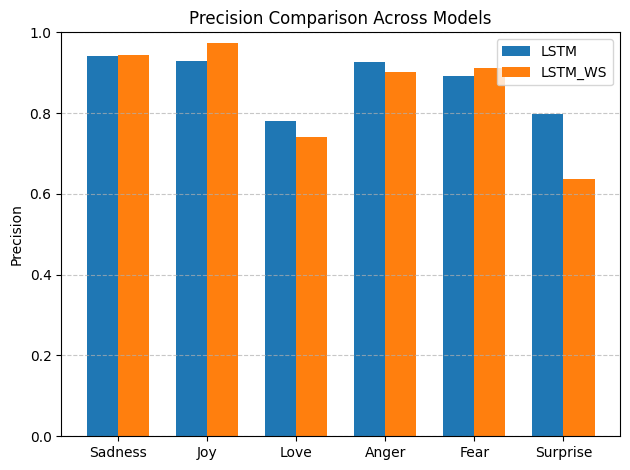

<Figure size 1000x600 with 0 Axes>

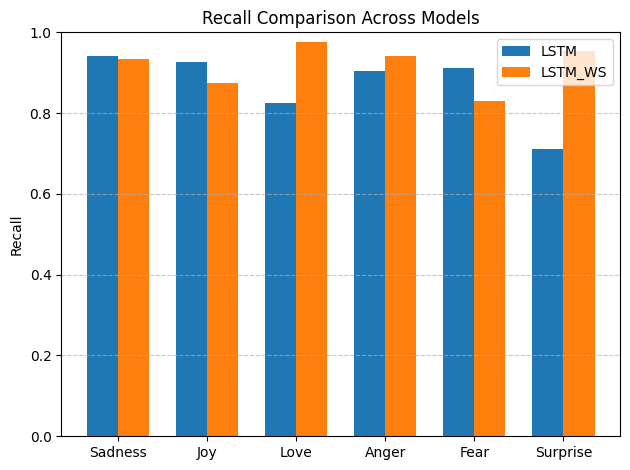

<Figure size 1000x600 with 0 Axes>

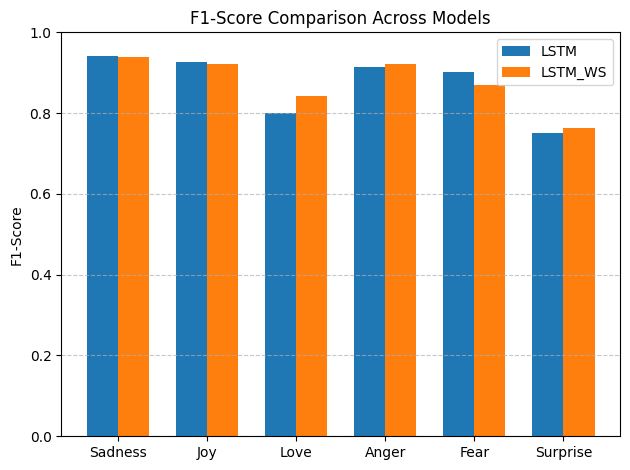

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ====== INPUT YOUR DATA HERE ======
classes = [idx_to_label[i] for i in range(6)]

# Model 1
p1 =   [0.941, 0.928, 0.780, 0.926, 0.891, 0.797]
r1 =   [0.941, 0.927, 0.824, 0.905, 0.911, 0.712]
f1_1 = [0.941, 0.927, 0.801, 0.915, 0.901, 0.752]

# Model 2
p2 =   [0.943, 0.973, 0.742, 0.902, 0.912, 0.636]
r2 =   [0.935, 0.875, 0.975, 0.942, 0.830, 0.955]
f1_2 = [0.939, 0.921, 0.842, 0.922, 0.869, 0.764]


# =================================

def plot_metric(metric_name, m1, m2):
    x = np.arange(len(classes))
    width = 0.35  # wider bars for 2 models

    plt.figure()
    plt.bar(x - width/2, m1, width, label='LSTM')
    plt.bar(x + width/2, m2, width, label='LSTM_WS')

    plt.xticks(x, classes)
    plt.ylim(0, 1)
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Comparison Across Models")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ====== PLOTS ======
plot_metric("Precision", p1, p2)
plot_metric("Recall", r1, r2)
plot_metric("F1-Score", f1_1, f1_2)

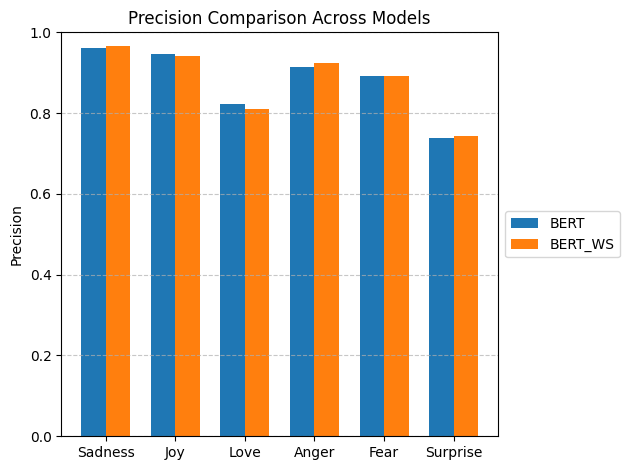

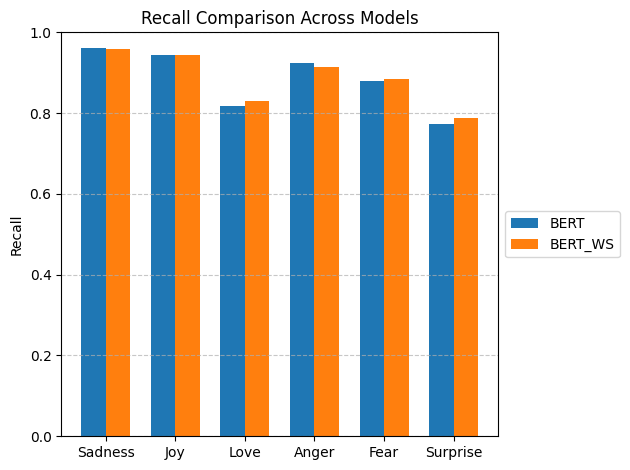

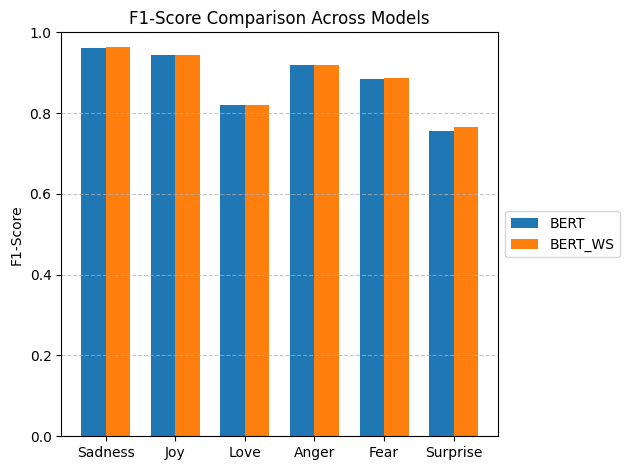

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# ====== INPUT YOUR DATA HERE ======
classes = [idx_to_label[i] for i in range(6)]

# Model 1
p1 =   [0.960, 0.947, 0.823, 0.914, 0.891, 0.739]
r1 =   [0.960, 0.944, 0.818, 0.924, 0.879, 0.773]
f1_1 = [0.960, 0.945, 0.820, 0.919, 0.885, 0.756]

# Model 2
p2 =   [0.967, 0.941, 0.810, 0.923, 0.892, 0.743]
r2 =   [0.959, 0.944, 0.830, 0.913, 0.884, 0.788]
f1_2 = [0.963, 0.943, 0.820, 0.918, 0.888, 0.765]


# =================================

def plot_metric(metric_name, m1, m2):
    x = np.arange(len(classes))
    width = 0.35  # wider bars for 2 models

    plt.figure()
    plt.bar(x - width/2, m1, width, label='BERT')
    plt.bar(x + width/2, m2, width, label='BERT_WS')

    plt.xticks(x, classes)
    plt.ylim(0, 1)
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Comparison Across Models")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# ====== PLOTS ======
plot_metric("Precision", p1, p2)
plot_metric("Recall", r1, r2)
plot_metric("F1-Score", f1_1, f1_2)

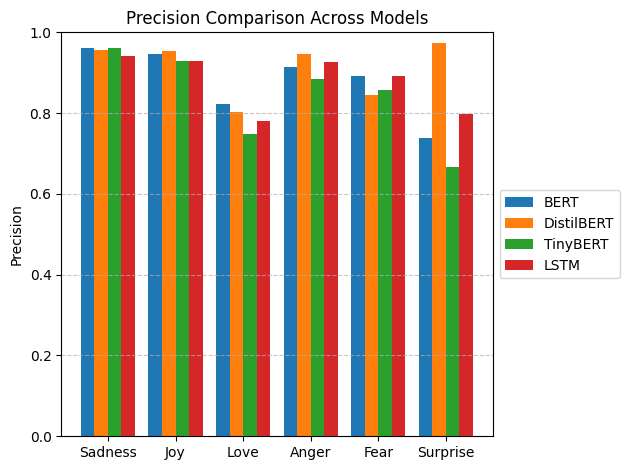

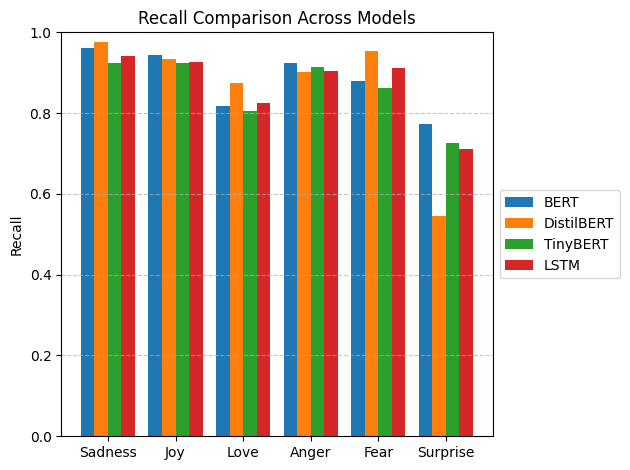

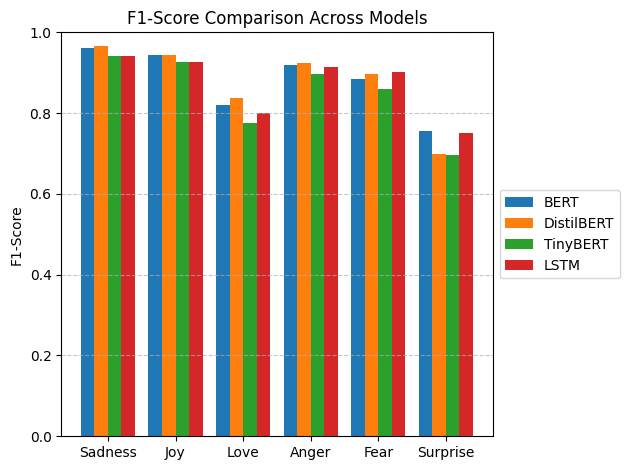

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# ====== INPUT YOUR DATA HERE ======
classes = [idx_to_label[i] for i in range(6)]

# Model 1
p1 =   [0.960, 0.947, 0.823, 0.914, 0.891, 0.739]
r1 =   [0.960, 0.944, 0.818, 0.924, 0.879, 0.773]
f1_1 = [0.960, 0.945, 0.820, 0.919, 0.885, 0.756]

# Model 2
p2 =   [0.956, 0.953, 0.803, 0.947, 0.846, 0.973]
r2 =   [0.976, 0.935, 0.874, 0.902, 0.955, 0.545]
f1_2 = [0.966, 0.944, 0.837, 0.924, 0.897, 0.699]


# Model 3
p3 =   [0.962, 0.929, 0.749, 0.884, 0.858, 0.667]
r3 =   [0.923, 0.924, 0.805, 0.913, 0.862, 0.727]
f1_3 = [0.942, 0.926, 0.776, 0.898, 0.860, 0.696]

p4   = [0.941, 0.928, 0.780, 0.926, 0.891, 0.797]
r4   = [0.941, 0.927, 0.824, 0.905, 0.911, 0.712]
f1_4 = [0.941, 0.927, 0.801, 0.915, 0.901, 0.752]


def plot_metric(metric_name, m1, m2, m3, m4):
    x = np.arange(len(classes))
    width = 0.2  # narrower bars for 4 models

    plt.figure()

    plt.bar(x - 1.5*width, m1, width, label='BERT')
    plt.bar(x - 0.5*width, m2, width, label='DistilBERT')
    plt.bar(x + 0.5*width, m3, width, label='TinyBERT')
    plt.bar(x + 1.5*width, m4, width, label='LSTM')

    plt.xticks(x, classes)
    plt.ylim(0, 1)
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Comparison Across Models")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# ====== PLOTS ======
plot_metric("Precision", p1, p2, p3, p4)
plot_metric("Recall", r1, r2, r3, r4)
plot_metric("F1-Score", f1_1, f1_2, f1_3, f1_4)

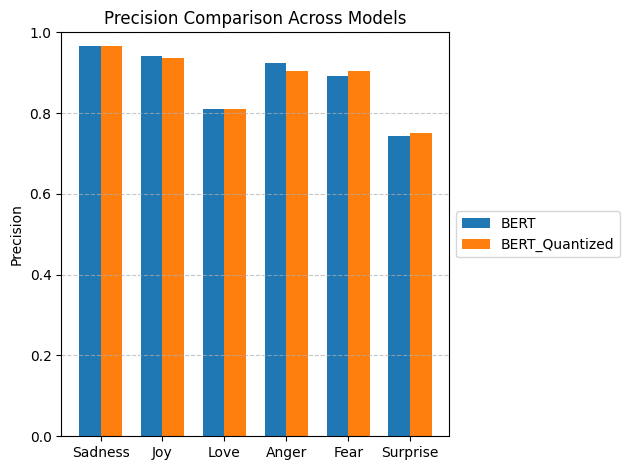

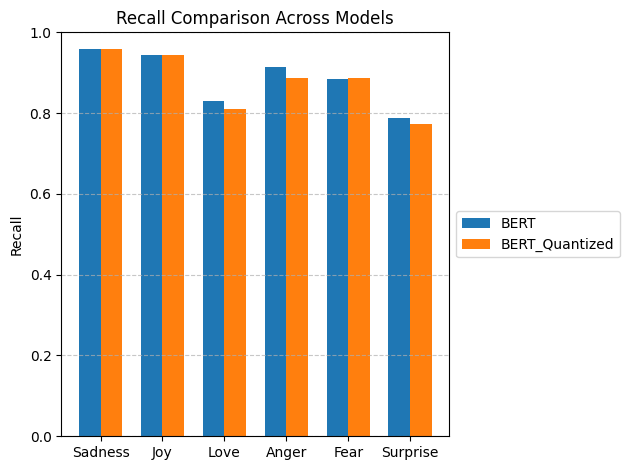

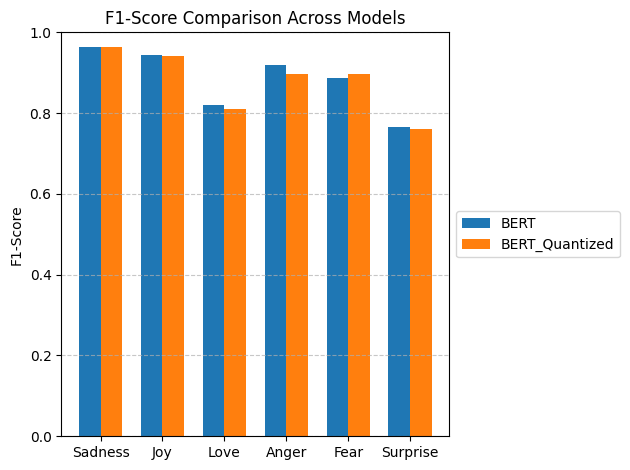

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# ====== INPUT YOUR DATA HERE ======
classes = [idx_to_label[i] for i in range(6)]

# Model 1
p1 =   [0.967, 0.941, 0.810, 0.923, 0.892, 0.743]
r1 =   [0.959, 0.944, 0.830, 0.913, 0.884, 0.788]
f1_1 = [0.963, 0.943, 0.820, 0.918, 0.888, 0.765]

# Model 2
p2 =   [0.967, 0.936, 0.811, 0.905, 0.905, 0.750]
r2 =   [0.959, 0.945, 0.811, 0.888, 0.888, 0.773]
f1_2 = [0.963, 0.941, 0.811, 0.896, 0.896, 0.761]


# =================================

def plot_metric(metric_name, m1, m2):
    x = np.arange(len(classes))
    width = 0.35  # wider bars for 2 models

    plt.figure()
    plt.bar(x - width/2, m1, width, label='BERT')
    plt.bar(x + width/2, m2, width, label='BERT_Quantized')

    plt.xticks(x, classes)
    plt.ylim(0, 1)
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Comparison Across Models")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# ====== PLOTS ======
plot_metric("Precision", p1, p2)
plot_metric("Recall", r1, r2)
plot_metric("F1-Score", f1_1, f1_2)